#Enviornment setup

In [1]:
# Installing the dependencies
%%capture
!pip install langchain_community tiktoken langchain_groq langchainhub chromadb langchain langgraph

# Optional: Install graph visualization dependencies and UPDATE IMPORTS
!pip install -U langchain langchain-core langchain-groq

!pip install pygraphviz --quiet
!pip install -U langsmith langchain

##Langsmith setup
###Tracing:
Optionally, use LangSmith for tracing (shown at bottom) by setting:


In [2]:
from google.colab import userdata
import os

os.environ['LANGSMITH_API_KEY'] = userdata.get('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ["LANGCHAIN_PROJECT"] = "Agentic RAG"

#LangGraph Retrieval Agent:
Retrieval Agents are usefull when we want to make decisions about whether to retrieve from an index.

To implement a retrieval agent, we simply need to give an llm access to retriever tool.

We can incorporate this into LANGGRAPH



##Retriever
First, we index 3 blog posts.

In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import SentenceTransformerEmbeddings

urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=1000, chunk_overlap=200
)
doc_splits = text_splitter.split_documents(docs_list)

# Add to vectorDB
vectorstore = Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chroma",
    embedding=SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2"),
)
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 8}  # Get more chunks
)

/tmp/ipython-input-1258787319.py:24: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding=SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2"),
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
# Check new chunk sizes
print(f"Total chunks: {len(doc_splits)}")
print(f"Average chunk length: {sum(len(chunk.page_content) for chunk in doc_splits) / len(doc_splits)}")

# Test retrieval
test_docs = retriever.invoke("types of agent memory")

for i, doc in enumerate(test_docs[:3]):
    print(f"\nRetrieved Doc {i}:")
    print(doc.page_content[:500])

Total chunks: 47
Average chunk length: 2961.808510638298

Retrieved Doc 0:
Memory

Short-term memory: I would consider all the in-context learning (See Prompt Engineering) as utilizing short-term memory of the model to learn.
Long-term memory: This provides the agent with the capability to retain and recall (infinite) information over extended periods, often by leveraging an external vector store and fast retrieval.


Tool use

The agent learns to call external APIs for extra information that is missing from the model weights (often hard to change after pre-training), 

Retrieved Doc 1:
LLM Powered Autonomous Agents | Lil'Log







































Lil'Log

















|






Posts




Archive




Search




Tags




FAQ









      LLM Powered Autonomous Agents
    
Date: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng


 


Table of Contents



Agent System Overview

Component One: Planning

Task Decomposition

Self-Reflection


Compon

Then we create a retriever tool.

In [5]:
from langchain_core.tools.retriever import create_retriever_tool
from langgraph.prebuilt import ToolNode  # <-- use the class

# Create retriever tool
retriever_tool= create_retriever_tool(
    retriever,
    name="retrieve_blog_posts",
    description="Search and return information about Lilian Weng blog posts on LLM agents, prompt engineering, and adversarial attacks on LLMs.",
)

# store tool in a list and dictionary for easy access
tools = [retriever_tool]
tools_dict = {tool.name: tool for tool in tools}


## Agent State

We are defining the graph’s state:  
- A `state` object is often passed around to every node in the graph.  
- In our case, the state will contain a list of `messages`.  
- Each node in the graph can read from and append to this state.


In [6]:
# Agent State - Updated to include tools
import operator
from typing import Annotated, Sequence, TypedDict, List
from langchain_core.messages import BaseMessage
from langchain_core.tools import BaseTool

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    tools: List[BaseTool]  # Add tools to state

## Nodes and Edges

We can create an agentic RAG graph as follows:  

- The state is a collection of messages.  
- Each node can read from the state and update it (e.g., by appending messages).  
- Conditional edges determine which node the graph should execute next, based on the current state or outputs.


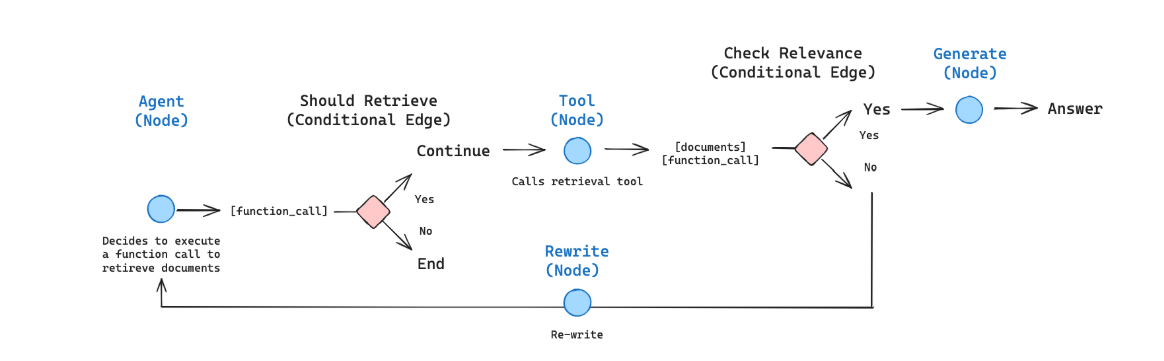

In [19]:
from IPython.display import Image, display
display(Image("/content/Screenshot 2025-10-24 014614.png"))

In [8]:
import json
from langchain_core.messages import BaseMessage, FunctionMessage, AIMessage
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from google.colab import userdata
from langchain_core.output_parsers import StrOutputParser
from langchain_core.output_parsers.openai_tools import PydanticToolsParser
from langchain_core.prompts import PromptTemplate


In [19]:
# Edge Functions
def should_retrieve(state):
    """
    Decides whether the agent should retrieve more information or end the process.
    """
    print("---- DECIDE TO RETRIEVE ----")
    messages = state["messages"]
    last_message = messages[-1]

    # Check if the last message contains a tool call indicator
    if hasattr(last_message, 'additional_kwargs') and "tool_calls" in last_message.additional_kwargs:
        print("Tool call found. Continuing retrieval.")
        return "continue"
    elif isinstance(last_message, AIMessage) and hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        print("Tool call found. Continuing retrieval.")
        return "continue"
    elif "retrieve_blog_posts" in last_message.content.lower():
        print("Retrieval needed based on content. Continuing.")
        return "continue"
    else:
        print("No retrieval needed. Ending process.")
        return "end"

In [20]:
# function for self reflection
def grade_docs(state):
    """
    Determines whether the retrieved documents are relevant to the question.
    """
    print("---CHECK RELEVANCE---")

    # Data model
    class GradeModel(BaseModel):
        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    llm = ChatGroq(
        groq_api_key=userdata.get('GROQ_API_KEY'),
        model="meta-llama/llama-4-scout-17b-16e-instruct",  # More stable model
        temperature=0
    )

    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of retrieved documents to a user question.

        Retrieved document:
        {context}

        User question:
        {question}

        If the document contains information related to the user question, respond with 'yes'.
        If the document is not relevant, respond with 'no'.

        Response (yes/no):""",
        input_variables=["context", "question"],
    )

    # Extract messages
    messages = state["messages"]
    question = messages[0].content

    # Get the retrieved documents from the last message
    last_message = messages[-1]
    docs = last_message.content

    # Create chain
    chain = prompt | llm | StrOutputParser()

    # Invoke
    response = chain.invoke({"question": question, "context": docs})

    # Parse response
    if "yes" in response.lower():
        print("---DECISION: DOCS RELEVANT---")
        return "yes"
    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        return "no"

In [21]:
# Node Functions
def agent(state):
    """
    Agent decides whether to retrieve information or provide final answer.
    """
    print("---CALL AGENT---")
    messages = state["messages"]

    llm = ChatGroq(
        groq_api_key=userdata.get('GROQ_API_KEY'),
        model="meta-llama/llama-4-scout-17b-16e-instruct",
        temperature=0
    )

    # Create a prompt that helps the agent decide
    system_prompt = """You are an AI assistant with access to a retrieval tool for Lilian Weng's blog posts.

When you receive a question:
1. If you need to search for information from the blog posts, respond with: "I need to retrieve information using retrieve_blog_posts"
2. If you have enough context from previous retrievals to answer the question, provide the answer directly.

Available tool: retrieve_blog_posts - searches Lilian Weng's blog posts about LLM agents, prompt engineering, and adversarial attacks.

Question: {question}

Current context: {context}"""

    # Get current context from previous messages
    context = ""
    if len(messages) > 1:
        context = "\n".join([msg.content for msg in messages[1:] if hasattr(msg, 'content')])

    question = messages[0].content

    prompt_text = system_prompt.format(question=question, context=context)

    response = llm.invoke([{"role": "user", "content": prompt_text}])

    return {"messages": [AIMessage(content=response.content)]}

In [22]:
def retrieve(state):
    """
    Execute retrieval using the retriever tool.
    """
    print("---EXECUTE RETRIEVAL---")
    messages = state["messages"]
    question = messages[0].content  # Original question

    # Use the retriever tool directly
    try:
        # Get the tool from our global tools list
        retrieval_result = retriever_tool.invoke({"query": question})

        # Format the result
        if isinstance(retrieval_result, list):
            content = "\n\n".join([doc.page_content for doc in retrieval_result])
        else:
            content = str(retrieval_result)

        print(f"Retrieved {len(retrieval_result)} documents")

        return {"messages": [FunctionMessage(content=content, name="retrieve_blog_posts")]}

    except Exception as e:
        error_msg = f"Error during retrieval: {str(e)}"
        print(error_msg)
        return {"messages": [FunctionMessage(content=error_msg, name="retrieve_blog_posts")]}

In [23]:
def rewrite(state):
    """
    Transform the query to produce a better question.
    """
    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    llm = ChatGroq(
        groq_api_key=userdata.get('GROQ_API_KEY'),
        model="meta-llama/llama-4-scout-17b-16e-instruct",
        temperature=0
    )

    rewrite_prompt = f"""Look at this question and rewrite it to be more specific and searchable:

Original question: {question}

Rewritten question should be:
- More specific and focused
- Use key terms that would be found in technical blog posts
- Maintain the original intent

Rewritten question:"""

    response = llm.invoke([{"role": "user", "content": rewrite_prompt}])

    # Replace the original question with the rewritten one
    new_question = response.content.strip()
    print(f"Rewritten question: {new_question}")

    return {"messages": [AIMessage(content=f"Searching for: {new_question}")]}

In [24]:
def generate(state):
    """
    Generate final answer using retrieved documents.
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content

    # Find the retrieved documents (last FunctionMessage)
    docs = ""
    for msg in reversed(messages):
        if isinstance(msg, FunctionMessage):
            docs = msg.content
            break

    llm = ChatGroq(
        groq_api_key=userdata.get('GROQ_API_KEY'),
        model="meta-llama/llama-4-scout-17b-16e-instruct",
        temperature=0
    )

    # RAG prompt
    rag_prompt = f"""Answer the question based on the following context from Lilian Weng's blog posts:

Context:
{docs}

Question: {question}

Provide a comprehensive answer based on the context. If the context doesn't contain enough information, say so clearly.

Answer:"""

    response = llm.invoke([{"role": "user", "content": rag_prompt}])

    return {"messages": [AIMessage(content=response.content)]}

Graph
- Start with an agent, call_model
- Agent make a decision to call a function
- If so, then action to call tool (retriever)
- Then call agent with the tool output added to messages (state)

In [25]:
# Build the Graph
from langgraph.graph import END, StateGraph

# Define the graph
workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("agent", agent)
workflow.add_node("retrieve", retrieve)
workflow.add_node("rewrite", rewrite)
workflow.add_node("generate", generate)

In [26]:
# Set entry point
workflow.set_entry_point("agent")

# Add conditional edges
workflow.add_conditional_edges(
    "agent",
    should_retrieve,
    {
        "continue": "retrieve",
        "end": END,
    },
)

workflow.add_conditional_edges(
    "retrieve",
    grade_docs,
    {
        "yes": "generate",
        "no": "rewrite",
    },
)

workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile the graph
app = workflow.compile()

=== PIPELINE GRAPH VISUALIZATION ===


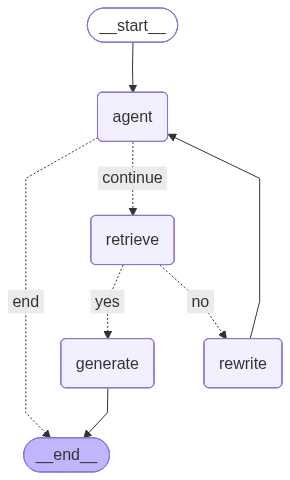

Graph visualization displayed above!

=== SIMPLE GRAPH REPRESENTATION ===
Flow: START → agent → [retrieve OR end]
      retrieve → [grade_docs: yes→generate, no→rewrite]
      generate → END
      rewrite → agent
Starting the agentic RAG pipeline...
---CALL AGENT---
---- DECIDE TO RETRIEVE ----
Retrieval needed based on content. Continuing.

=== Output from node 'agent' ===
Content: I need to retrieve information using retrieve_blog_posts.
---EXECUTE RETRIEVAL---
Retrieved 17477 documents
---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---

=== Output from node 'retrieve' ===
Content: Citation#
Cited as:

Weng, Lilian. (Jun 2023). “LLM-powered Autonomous Agents”. Lil’Log. https://lilianweng.github.io/posts/2023-06-23-agent/.

Or
@article{weng2023agent,
  title   = "LLM-powered Autonomous Agents",
  author  = "Weng, Lilian",
  journal = "lilianweng.github.io",
  year    = "2023",
  month   = "Jun",
  url     = "https://lilianweng.github.io/posts/2023-06-23-agent/"
}
References#
[1] Wei 

In [27]:
# Visualize the graph
print("=== PIPELINE GRAPH VISUALIZATION ===")
from IPython.display import Image, display

try:
    # Try to display the graph visualization
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
    print("Graph visualization displayed above!")
except Exception as e:
    print(f"Could not display graph image: {e}")
    print("You may need to install: pip install pygraphviz")

    # Fallback: Print the mermaid diagram as text
    try:
        mermaid_syntax = app.get_graph(xray=True).draw_mermaid()
        print("\nMermaid diagram (copy to https://mermaid.live for visualization):")
        print("=" * 60)
        print(mermaid_syntax)
        print("=" * 60)
    except Exception as e2:
        print(f"Could not generate mermaid syntax: {e2}")

# Alternative: Simple text representation
print("\n=== SIMPLE GRAPH REPRESENTATION ===")
print("Flow: START → agent → [retrieve OR end]")
print("      retrieve → [grade_docs: yes→generate, no→rewrite]")
print("      generate → END")
print("      rewrite → agent")

# Test the pipeline
import pprint
from langchain_core.messages import HumanMessage

# Run the pipeline
inputs = {
    "messages": [
        HumanMessage(content="What does Lilian Weng say about the types of agent memory?")
    ],
    "tools": tools  # Now tools is properly defined
}

print("Starting the agentic RAG pipeline...")
for output in app.stream(inputs):
    for key, value in output.items():
        print(f"\n=== Output from node '{key}' ===")
        if "messages" in value and value["messages"]:
            latest_message = value["messages"][-1]
            print(f"Content: {latest_message.content}")
        print("=" * 50)

Trace:
https://smith.langchain.com/public/0b4bc8fa-d292-4668-9f37-ea96f7ff6bb8/r